<a href="https://colab.research.google.com/github/DemydovaAnna/python_for_da_tasks/blob/main/Copy_of_HW_11_1_%D0%92%D1%96%D0%B7%D1%83%D0%B0%D0%BB%D1%96%D0%B7%D0%B0%D1%86%D1%96%D1%8F_%D0%B4%D0%B0%D0%BD%D0%B8%D1%85_%D0%B7_Pandas_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Домашнє завдання: Візуалізація даних з Pandas

## Опис завдання
У цьому домашньому завданні ви працюватимете з датасетом про оренду велосипедів `yulu_rental.csv`. Датасет містить інформацію про кількість орендованих велосипедів залежно від погодних умов, сезону та інших факторів.
Набір даних взяти з Kaggle. Посилання на оригінальний [опис](https://www.kaggle.com/datasets/ranitsarkar01/yulu-bike-sharing-data?select=yulu_bike_sharing_dataset.csv).

**Опис колонок:**
- `datetime` - дата та час
- `season` - квартал (1-Q1, 2-Q2, 3-Q3, 4-Q4)
- `holiday` - чи є день святковим (0=ні, 1=так)
- `workingday` - чи є день робочим (0=ні, 1=так)
- `weather` - погодні умови (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ)
- `temp` - температура в градусах Цельсія
- `atemp` - відчувається як температура
- `humidity` - вологість (%)
- `windspeed` - швидкість вітру
- `casual` - кількість випадкових користувачів
- `registered` - кількість зареєстрованих користувачів
- `count` - загальна кількість орендованих велосипедів



---
🌱 Коментар щодо сезонності

Колонка season у датасеті представляє саме квартали року, а не метеорологічні сезони. Тому всі аналізи сезонності ви можете будувати на основі кварталів.

Водночас дані були зібрані в Індії, де поділ на сезони інший, ніж у Європі чи США. Якщо ви хочете дослідити сезонність відповідно до індійської системи сезонів, можна створити окрему колонку.


Справжні сезони в Індії:

| Сезон        | Місяці                     |
| ------------ | -------------------------- |
| Winter       | December–February (12,1,2) |
| Summer       | March–May (3,4,5)          |
| Monsoon      | June–September (6,7,8,9)   |
| Post-monsoon | October–November (10,11)   |


Тоді потрібно зробити нову колонку weather_season_india, мапнувши місяці так:

12, 1, 2 → 1 (Winter)

3, 4, 5 → 2 (Summer)

6–9 → 3 (Monsoon)

10–11 → 4 (Post-Monsoon)

## Підготовка даних


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Завантаження даних
df = pd.read_csv('yulu_rental.csv')

In [2]:
# Перетворення datetime у правильний формат
df['datetime'] = pd.to_datetime(df['datetime'])
df.set_index('datetime', inplace=True)

# Додамо додаткові колонки для аналізу
df['date'] = df.index.date
df['day'] = df.index.day
df['week'] = df.index.isocalendar().week
df['weekday_num'] = df.index.weekday
df['weekday'] = df.index.day_name()
df['year'] = df.index.year
df['month'] = df.index.month
df['hour'] = df.index.hour

## Завдання 0: Перегляд даних
**Завдання:**
Перегляньте дані, їх розмір, та напишіть висновок:
- скільки даних в наборі
- який рівень деталізації мають ці дані, тобто за який період міститься дані в одному рядку даних ?

In [3]:
print("Розмірність датасету (рядки, колонки):", df.shape)

Розмірність датасету (рядки, колонки): (10886, 19)


In [4]:
df.head()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,date,day,week,weekday_num,weekday,year,month,hour
datetime,,,,,,,,,,,,,,,,,,,
2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16,2011-01-01,1,52,5,Saturday,2011,1,0
2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40,2011-01-01,1,52,5,Saturday,2011,1,1
2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32,2011-01-01,1,52,5,Saturday,2011,1,2
2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13,2011-01-01,1,52,5,Saturday,2011,1,3
2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1,2011-01-01,1,52,5,Saturday,2011,1,4


**Висновки:**

Кількість даних: У наборі міститься 10 886 рядків та 19 колонок.

Рівень деталізації: Дані мають погодинну деталізацію.

## Завдання 1: Базовий лінійний графік

**Завдання:**
1. Згрупуйте дані про кількість орендованих велосипедів (`count`) поденно.
2. Побудуйте з методом `DataFrame.plot()` лінійний графік поденної кількості орендованих велосипедів (`count`) за весь період в даних.
3. Налаштуйте розмір графіка (12x6), додайте заголовок "Динаміка оренди велосипедів" та сітку.
4. Дайте відповіді на питання по цьому графіку. Якщо треба - проведіть додаткові програмні операції для відповідей.

**Питання для інтерпретації:**
1. Як гадаєте, чому графік має "заломи", чим це спричинено і як ви б могли прибрати заломи?
2. Які загальні тенденції ви бачите на графіку?
3. Чи помітні якісь сезонні коливання?
4. Чи є періоди з аномально високими або низькими значеннями і чому на ваш погляд можуть бути ці аномалії?


In [10]:
daily_count = df.groupby('date')['count'].sum()

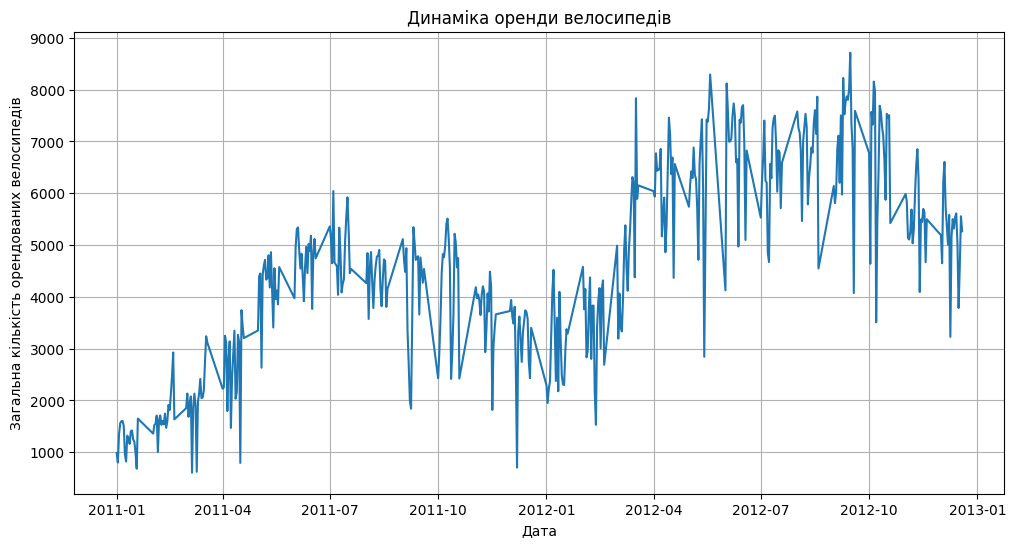

In [14]:
daily_count.plot(
    kind='line',
    figsize=(12, 6),
    title='Динаміка оренди велосипедів',
    xlabel='Дата',
    ylabel='Загальна кількість орендованих велосипедів',
    grid=True
);

In [15]:
print(df['day'].unique())

[ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19]


1. Як гадаєте, чому графік має "заломи", чим це спричинено і як ви б могли прибрати заломи?

Гострі "заломи" виникають через щоденні коливання попиту (наприклад, різниця між робочими та вихідними днями, або раптова зміна погоди з дня на день). Також між місяцями є розриви в датах, які лінія просто з'єднує напряму.

Як прибрати: Додати ковзне середнє (rolling mean), щоб згладити лінію.

2. Які загальні тенденції ви бачите на графіку?

Загальний тренд зростання. Чітко видно, що у 2012 році рівень оренди в середньому значно вищий, ніж у 2011 році.

3. Чи помітні якісь сезонні коливання?

 Так, дуже помітні: Влітку та восени (середина року) лінія виходить на піки (до 8000+ орендованих велосипедів).
 Взимку (на початку та в кінці року) спостерігається сильне падіння вниз.

4. Чи є періоди з аномально високими або низькими значеннями і чому на ваш погляд можуть бути ці аномалії?

Низькі аномалії: Окремі дні з дуже поганою погодою (наприклад, злива, шторм або сильний мороз).

Високі аномалії: Теплі сонячні вихідні або святкові дні, коли попит максимально зростає.


## Завдання 2: Аналіз сезонності (Bar Plot)

**Завдання:**
Побудуйте вертикальну стовпчасту діаграму середньої кількості орендованих велосипедів за сезонами(кварталами). Додайте підписи осей і заголовок.

Просунуте доповнення:
1. Позначте квартали не числом, а назвою на візуалізації.
2. Додайте підписи над стовпцями зі значеннями в кожному стовпці.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. В який квартал найбільша середня кількість оренди велосипедів?
2. Як ви можете пояснити таку сезонну закономірність?
3. У скільки разів відрізняється оренда між найпопулярнішим та найменш популярним кварталми?

In [17]:
season_mean = df.groupby('season')['count'].mean()

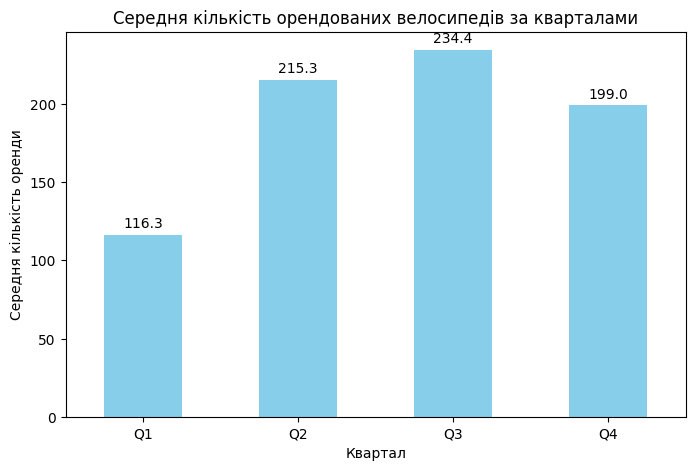

In [22]:
ax = season_mean.plot.bar(
    figsize=(8, 5),
    color='skyblue',
    rot=0,
    title="Середня кількість орендованих велосипедів за кварталами",
    xlabel="Квартал",
    ylabel="Середня кількість оренди"
)
plt.xticks(ticks=[0, 1, 2, 3], labels=['Q1', 'Q2', 'Q3', 'Q4'])
plt.bar_label(ax.containers[0], fmt='%.1f', padding=3);

1. В який квартал найбільша середня кількість оренди велосипедів?

У третьому кварталі.

2. Як ви можете пояснити таку сезонну закономірність?

Влітку та на початку осені (Q3) найсприятливіша погода для поїздок. У 1-му кварталі (Q1 зима) попит найнижчий через холод та опади.

3. У скільки разів відрізняється оренда між найпопулярнішим та найменш популярним кварталми?

Приблизно у 2 рази (у Q3 середня оренда = 234.4, а в Q1 = 116.3)


## Завдання 3: Динаміка за місяцями (Line Plot)

**Завдання:**
Створіть лінійний графік середньої кількості оренди велосипедів по місяцях (тобто групування в рамках місяця і беремо середню кількість оренд в цей місяць з кількох років). Використайте маркери-кружечки для точок, додайте сітку та пофарбуйте лінію у червоний колір.

Просунуте доповнення:
- додайте аби по осі ОХ поділки були чітко на кожен окремий місяць по одній. Тобто сумарно 12 поділок.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. В які місяці спостерігається пік та спад оренди?
2. Чи збігається ця закономірність з результатами з попереднього завдання?
3. Як може вплинути клімат на оренду велосипедів протягом року?


In [23]:
monthly_mean = df.groupby('month')['count'].mean()

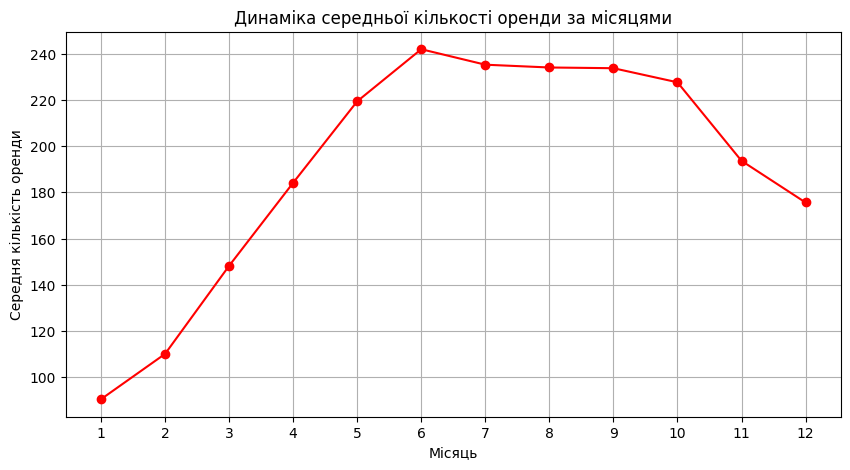

In [24]:
ax = monthly_mean.plot(
    kind='line',
    figsize=(10, 5),
    color='red',
    marker='o',
    grid=True,
    title="Динаміка середньої кількості оренди за місяцями",
    xlabel="Місяць",
    ylabel="Середня кількість оренди" )
plt.xticks(range(1, 13))
plt.show()

1. В які місяці спостерігається пік та спад оренди?

Пік оренди: Спостерігається з травня по жовтень (місяці 5–10), із максимальним значенням у червні.

Спад оренди: Припадає на зимові місяці грудень, січень та лютий (місяці 12, 1, 2), де січень має мінімальне значення.

2. Чи збігається ця закономірність з результатами з попереднього завдання?

 Так, повністю збігається. Помісячний графік детально розкриває картину з Завдання 2: найвищі показники припадають саме на місяці 3-го кварталу (Q3: червень, липень, серпень, вересень), а найнижчі на місяці 1-го кварталу (Q1: грудень, січень, лютий,).

3. Як може вплинути клімат на оренду велосипедів протягом року?

Тепла та помірна погода навесні, влітку й восени стимулює містян та туристів користуватися велосипедами для прогулянок і поїздок на роботу.
Мороз, сніг, зливи та короткий світловий день узимку суттєво знижують комфорт і безпеку катання, через що попит падає до мінімальних позначок.


## Завдання 4: Розподіл погодних умов (Pie Chart)

**Завдання:**
1. Побудуйте кругову діаграму з часткою записів за погодними умовами
2. Додайте підписи з відсотками та легенду з описами погоди (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ).
3. Визначте свої відмінні від стандартних кольори для відображення кожної категорії.
4. Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. Яка погода переважає в датасеті?
2. Чи є дні із сильним дощем? Яка їх частка?
3. Як ви думаєте, як погодні умови впливають на попит на оренду велосипедів?

Очікуваний результат:

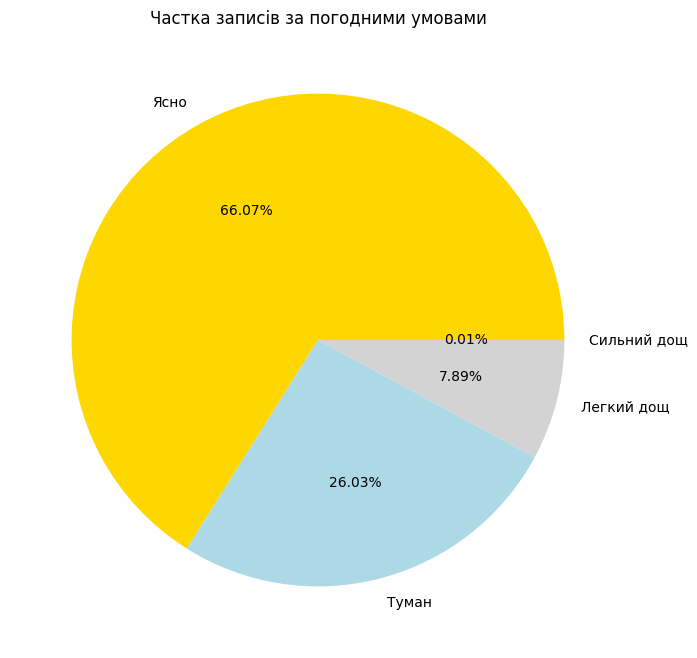

In [25]:
weather_counts = df['weather'].value_counts().sort_index()

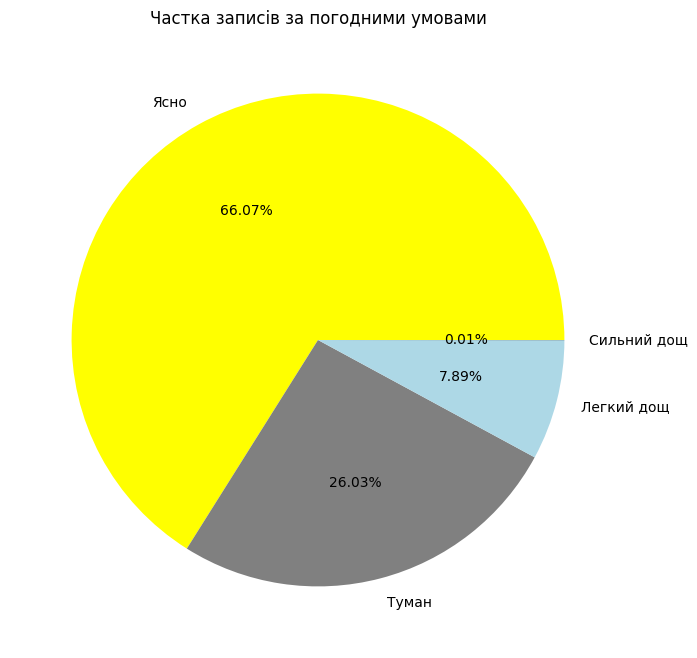

In [29]:
weather_counts.plot.pie(
    figsize=(8, 8),
    labels=['Ясно', 'Туман', 'Легкий дощ', 'Сильний дощ'],
    colors=['yellow', 'grey', 'lightblue', 'black'],
    autopct='%1.2f%%',
    title="Частка записів за погодними умовами",
    ylabel=''
);

1. Яка погода переважає в датасеті?

Переважає сонячна та ясна погода, вона становить 66.07% від усіх записів у датасеті.

2. Чи є дні із сильним дощем? Яка їх частка?

Так, але їхні значення екстремально рідкісні. Частка категорії «Сильний дощ» становить всього 0.01%

3. Як ви думаєте, як погодні умови впливають на попит на оренду велосипедів?

Прямий зв'язок: Гарна та ясна погода створює максимальний попит на оренду. Погіршення умов до туману помірно знижує кількість поїздок, а опади («Легкий дощ» та особливо «Сильний дощ») знижують попит, оскільки пересування на велосипеді стає некомфортним та небезпечним.


## Завдання 5: Box Plot для аналізу викидів

**Завдання:**
Створіть коробковий графік (box plot) кількості орендованих велосипедів для кожного типу погоди.

Просунуте доповнення:
- Використайте горизонтальну орієнтацію.
- Позначте погодні умови не числом, а назвою на візуалізації.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. При якій погоді найбільший розкид у кількості оренди?
2. Чи є викиди (outliers) в даних? При якій погоді?
3. При якій погоді медіанне значення оренди найвище?

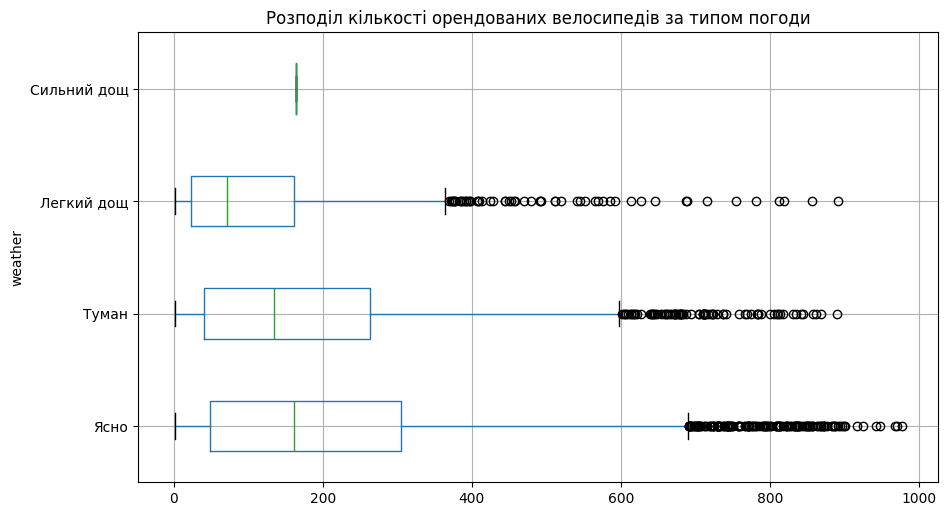

In [39]:
ax = df.boxplot(
    column='count',
    by='weather',
    vert=False,
    figsize=(10, 6)
)
plt.title("Розподіл кількості орендованих велосипедів за типом погоди")
plt.suptitle("")
plt.yticks(ticks=[1, 2, 3, 4], labels=['Ясно', 'Туман', 'Легкий дощ', 'Сильний дощ'])
plt.show()

1. При якій погоді найбільший розкид у кількості оренди?

При погоді «Ясно». Міжквартильний розмах (ширина "коробки") та довжина "вусів" тут найбільші, що свідчить про високу варіативність попиту (від майже 0 до сотень велосипедів на годину).

2. Чи є викиди (outliers) в даних? При якій погоді?

Так, викиди є. Вони найбільш виражені при погоді «Ясно» «Туман» та «Легкий дощ»  (там є багато аномально високих значень оренди у пікові години). При «Сильному дощі» викидів немає, оскільки там взагалі одиничні записи.

3. При якій погоді медіанне значення оренди найвище?

При погоді «Ясно» (вертикальна лінія всередині коробки знаходиться найправіше, тобто значення медіани є найвищим)


## Завдання 6: Кореляція температури та оренди (Scatter Plot)

**Завдання:**
Побудуйте діаграму розсіювання залежності між температурою (`temp`) та загальною кількістю оренди (`count`). Розфарбуйте точки за сезонами, додайте напівпрозорість (alpha=0.6).

**Увага!** За замовченням буде колір

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
- Чи є зв'язок між температурою та кількістю оренди? Який?

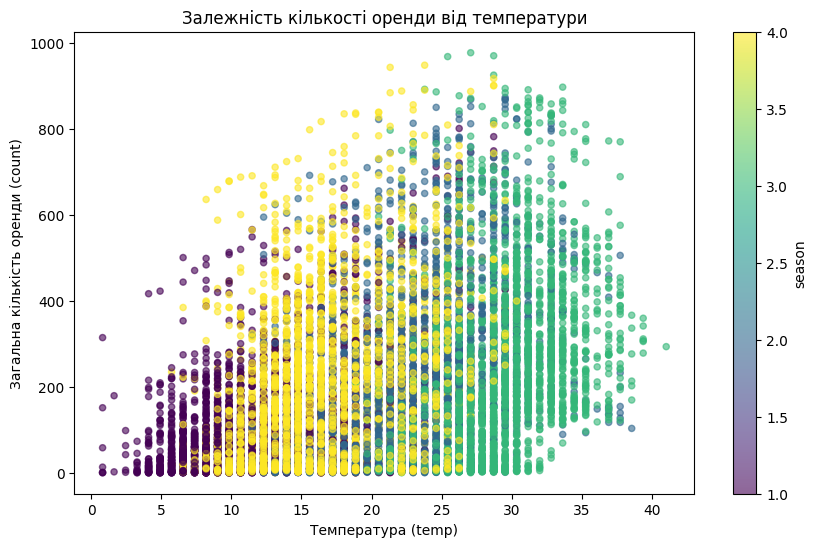

In [41]:
ax = df.plot.scatter(
    x='temp',
    y='count',
    c='season',
    colormap='viridis',
    alpha=0.6,
    figsize=(10, 6),
    title="Залежність кількості оренди від температури"
)
plt.xlabel("Температура (temp)")
plt.ylabel("Загальна кількість оренди (count)")
plt.show()

Чи є зв'язок між температурою та кількістю оренди? Який?

Це пряма позитивна кореляція. Зі зростанням температури кількість орендованих велосипедів збільшується (люди активніше катаються у теплу погоду). Проте при екстремально високих температурах (найправіші точки) спостерігається невелике плато або навіть спад попиту через спеку.

## (Опціонально) Завдання 7: Порівняння користувачів (Stacked Bar Chart)

**Завдання:**
Ми хочемо дізнатись як по дням тижня беруть в середньому в оренду велосипеди випадкові і зареєстровані користувачі.

Створіть стовпчасту діаграму з накопиченням (bar з налаштуванням `stacked=True`), яка показує співвідношення випадкових (`casual`) та зареєстрованих (`registered`) користувачів по днях тижня за кількістю взятих ними велосипедів в оренду в середньому. Використайте різні кольори для типів користувачів.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. В які дні тижня більше оренд від зареєстрованих користувачів?
2. Як ви можете пояснити таку різницю в поведінці користувачів протягом тижня?

In [49]:
days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
users_by_weekday = df.groupby('weekday')[['casual', 'registered']].mean().reindex(days)

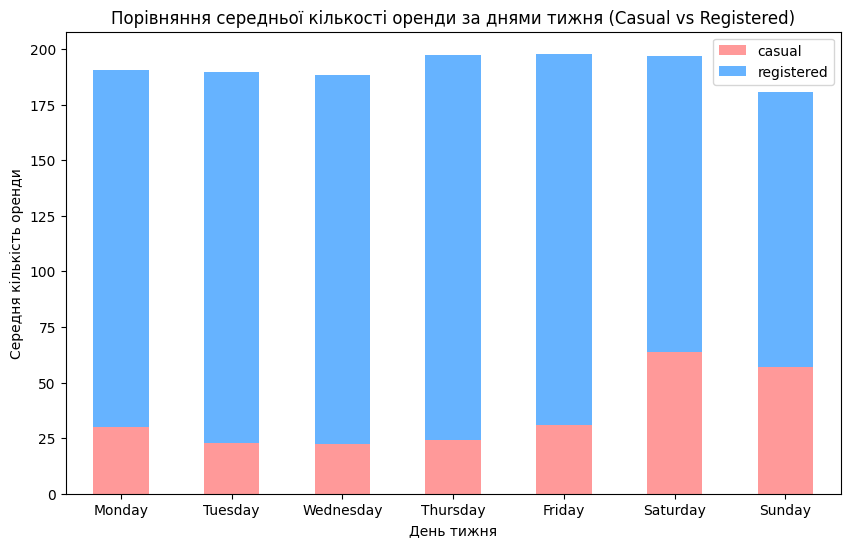

In [50]:
ax = users_by_weekday.plot(
    kind='bar',
    stacked=True,
    figsize=(10, 6),
    color=['#ff9999', '#66b3ff'],
    rot=0,
    title="Порівняння середньої кількості оренди за днями тижня (Casual vs Registered)",
    xlabel="День тижня",
    ylabel="Середня кількість оренди"
)
plt.show()

1. В які дні тижня більше оренд від зареєстрованих користувачів?

Зареєстровані користувачі (⁠registered⁠) переважають абсолютно в усі дні тижня. Проте більше оренд від зареєстрованих користувачів (⁠registered⁠) спостерігається у робочі дні (з понеділка по п'ятницю).

2. Як ви можете пояснити таку різницю в поведінці користувачів протягом тижня?

Зареєстровані користувачі (⁠registered⁠) користуються підпискою регулярно як міським транспортом для поїздок на роботу та навчання (через що блакитна частина висока у будні — з понеділка по п'ятницю).
Випадкові користувачі (⁠casual⁠) беруть велосипеди ситуативно для прогулянок та відпочинку у вільний час (тому рожева частина суттєво зростає саме на вихідних — у суботу та неділю).
